# North San Andreas fault M7.6 Scenario

## 1. Setup

In [1]:
import os, json, shutil
from pathlib import Path
import xml.etree.ElementTree as ET
from xml.dom import minidom
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

EVENT = 'bssc2014nsanandreassapsassha_m7p6_se'
os.environ['EVENT'] = EVENT

EVENT_DIR = Path.home() / 'shakemap_profiles/default/data' / EVENT / 'current'
PRODUCTS  = EVENT_DIR / 'products'
GF_OUT    = Path.home() / 'gf_output' / EVENT
CA_DATA   = Path('/workspaces/shakemap-gf-workshop/data/california_inputs')
PAGER_DIR = Path('/workspaces/shakemap-gf-workshop/data/pager/json/cali')
PAGER_PNG = Path('/workspaces/shakemap-gf-workshop/data/pager/onepager.png')

In [2]:
print(EVENT_DIR)

/home/vscode/shakemap_profiles/default/data/bssc2014nsanandreassapsassha_m7p6_se/current


Note: expect the "shake -v" command to take about 1 minute.

In [3]:
%%bash
shake -v

ShakeMap version 0.1.dev1+g683bff506


You can also get help on how to use the commands with the `-h` option

In [4]:
%%bash
shake -h

usage: shake [-h] [-d] [-q] [-l] [-f] [-c COMMENT] [-x] [-y] [-v]
             [-pv PRODUCT_VERSION]
             eventid ...

    Run specified ShakeMap modules.
    

positional arguments:
  eventid               The id of the event to process.
  cmds                  The modules to run.

options:
  -h, --help            show this help message and exit
  -d, --debug           Print all informational messages.
  -q, --quiet           Print only errors.
  -l, --log             Log all output.
  -f, --force           Force the command(s) to run regardless of out of date
                        dependencies.
  -c COMMENT, --comment COMMENT
                        Provide a comment for 'assemble' in this version of
                        the ShakeMap. If the comment has spaces, the string
                        should be quoted (e.g., --comment "This is a
                        comment.")
  -x, --cancel          Cancel shakemap; execute cancel_modules list in
                        sh

---

# SHAKEMAP

---

## 2. Run ShakeMap

ShakeMap combines three types of input to estimate ground shaking:
- **Earthquake origin** — location, magnitude, depth, and fault geometry (`event.xml` + `rupture.json`)
- **Ground motion models (GMMs)** — equations that predict shaking from earthquakes
- **Site conditions (Vs30)** — local geology that amplifies or de-amplifies shaking (soft soils shake more than rock)

Now we will explore these system files.

In [5]:
event_xml_path = EVENT_DIR / "event.xml"
rupture_json_path = EVENT_DIR / "rupture.json"
print(event_xml_path)
print(rupture_json_path)

/home/vscode/shakemap_profiles/default/data/bssc2014nsanandreassapsassha_m7p6_se/current/event.xml
/home/vscode/shakemap_profiles/default/data/bssc2014nsanandreassapsassha_m7p6_se/current/rupture.json


For viewing and editing the JSON files, installing a VS Code extension like "Prettify JSON" is helpful.

We can also read and print the contents with Python in this notebook.

In [10]:
# First, read and print the event.xml file
print(minidom.parse(str(event_xml_path)).toprettyxml(indent="  "))

<?xml version="1.0" ?>
<earthquake id="bssc2014nsanandreassapsassha_m7p6_se" netid="bssc2014" network="bssc2014" lat="37.2972" lon="-122.1401" depth="7.8" mag="7.6" time="2017-06-30T16:03:44Z" locstring="N. San Andreas: SAP+SAS" mech="ALL" event_type="SCENARIO" reviewed="unknown"/>



In [11]:
# Now read the rupture.json file
with rupture_json_path.open(encoding="utf-8") as f:
    rupture = json.load(f)
print(type(rupture))

<class 'dict'>


In [12]:
# It is a dictionary, so check the keys
print(rupture.keys())

dict_keys(['type', 'metadata', 'features'])


In [13]:
# Now we can inspect some of the keys
print(rupture["metadata"])

{'mag': 7.6, 'timezone': 'UTC', 'rake': 0.0, 'locstring': 'N. San Andreas: SAP+SAS', 'mech': 'ALL', 'id': 'bssc2014nsanandreassapsassha_m7p6_se', 'lon': -122.14005, 'depth': 7.8, 'lat': 37.29721, 'created': '2017-06-30T16:03:44Z', 'type': 'ALL', 'time': '2017-06-30T16:03:44', 'reference': '', 'netid': 'bssc2014', 'network': 'bssc2014', 'event_type': 'SCENARIO', 'reviewed': 'unknown'}


In [14]:
print(type(rupture["features"]))

<class 'list'>


In [15]:
# "features" is a list, so it is useful to know how long it is
print(len(rupture["features"]))

1


In [28]:
# Length is 1 so there is one "feature" but we know that the feature is a 
# complicated structure called a multipolygon and each feature is a dictionary
print(type(rupture["features"][0]))
print(rupture["features"][0].keys())

<class 'dict'>
dict_keys(['type', 'properties', 'geometry'])


In [30]:
# The verticies are in the "geometry" key, which is a dictionary
print(type(rupture["features"][0]["geometry"]))
print(rupture["features"][0]["geometry"].keys())


<class 'dict'>
dict_keys(['type', 'coordinates'])


In [33]:
# "coordinates" is a list
print(type(rupture["features"][0]["geometry"]["coordinates"]))
print(len(rupture["features"][0]["geometry"]["coordinates"]))


<class 'list'>
1


In [ ]:
# This is the a complicated "mulgipolygon" structure, but at the top
# level it is a list of length 1. It contains a 25 element list.
print(type(rupture["features"][0]["geometry"]["coordinates"][0]))
print(len(rupture["features"][0]["geometry"]["coordinates"][0]))

<class 'list'>
25


In [36]:
# We don't wnat to inspect each on, so let's just look at the first
print(type(rupture["features"][0]["geometry"]["coordinates"][0][0]))
print(len(rupture["features"][0]["geometry"]["coordinates"][0][0]))

<class 'list'>
17


In [37]:
# This is again a long list, so let's just look at the first
print(type(rupture["features"][0]["geometry"]["coordinates"][0][0][0]))
print(len(rupture["features"][0]["geometry"]["coordinates"][0][0][0]))

<class 'list'>
3


In [38]:
# This is a list of the verticies of the individual rupture quadrilaterals
print(rupture["features"][0]["geometry"]["coordinates"][0][0][0])

[-122.66515, 37.89651, 0.0]


Four modules run in sequence:
- **`assemble`** — collect and validate all inputs
- **`model`** — compute ground motion at every grid point (computationally intense; about 1 minute to finish)
- **`contour`** — generate MMI shaking contour lines
- **`mapping`** — render map images (can take 30-45s)
- **`gridxml`** — export the grid file needed for ground failure models

Please be patient as it may take 1-2 minutes to run.

In [14]:
%%bash
shake $EVENT assemble -c 'demo' model contour mapping gridxml

INFO -- 2026-08-31 09:17:57 -- shake.main -- Running command assemble
INFO -- 2026-08-31 09:17:58 -- shake.main -- Finished running command assemble: Elapsed 0.45 secs
INFO -- 2026-08-31 09:17:58 -- shake.main -- Running command model
INFO -- 2026-08-31 09:17:58 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-31 09:17:58 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-31 09:17:58 -- output_grid._adjust_resolution -- Resolution units specified in km, converting to degrees.
INFO -- 2026-08-31 09:17:58 -- output_grid._adjust_resolution -- Updated dx: 0.0169922 (degrees)
INFO -- 2026-08-31 09:17:58 -- output_grid._adjust_resolution -- Updated dy: 0.0134898 (degrees)
INFO -- 2026-08-31 09:18:27 -- shake.main -- Finished running command model: Elapsed 29.34 secs
INFO -- 2026-08-31 09:18:27 -- shake.main -- Running command contour
INFO -- 2026-08-31 09:18:30 -- shake.main 

## 3. ShakeMap maps

We will plot the **Modified Mercalli Intensity (MMI)** map — which
describes felt shaking in human terms — and the **Peak Ground Acceleration (PGA)**
map, which is used in engineering design.

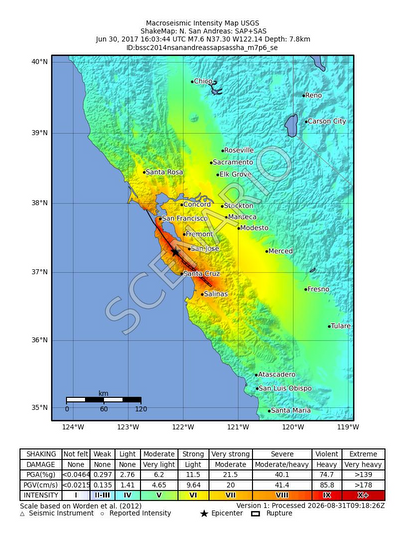

In [28]:
img = mpimg.imread(str(PRODUCTS / 'intensity.jpg'))
h, w = img.shape[:2]
fig, ax = plt.subplots(figsize=(w/300, h/300), dpi=150)
ax.imshow(img, interpolation='lanczos')
ax.axis('off')
plt.tight_layout(pad=0)
plt.show()

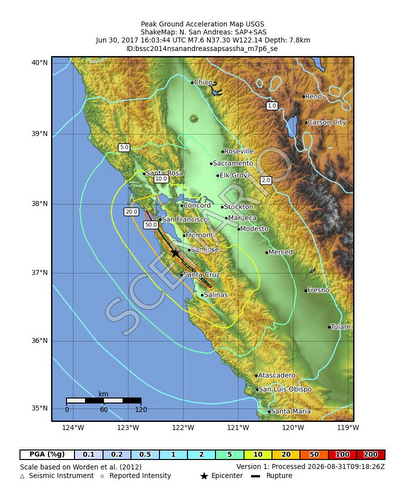

In [29]:
img = mpimg.imread(str(PRODUCTS / 'pga.jpg'))
h, w = img.shape[:2]
fig, ax = plt.subplots(figsize=(w/300, h/300), dpi=150)
ax.imshow(img, interpolation='lanczos')
ax.axis('off')
plt.tight_layout(pad=0)
plt.show()

---

# PAGER - Loss estimates

---

PAGER estimates fatalities and economic losses using ShakeMap grids combined with
with population data and country-level vulnerability models.

### Population exposure

`exposures.json` contains the number of people estimated to experience
each MMI level, based on LandScan population data and the ShakeMap grid.

In [19]:
with open(PAGER_DIR / 'exposures.json') as f:
    exposures = json.load(f)

exp = exposures['population_exposure']
labels = ['Not felt','Not felt','Weak','Light','Moderate',
          'Strong','Very Strong','Severe','Violent','Extreme']
print(f'{"MMI":<6} {"Population":>15}   Shaking')
print('-' * 42)
for mmi, pop, label in zip(exp['mmi'], exp['aggregated_exposure'], labels):
    if pop > 0:
        print(f'{mmi:<6} {pop:>15,}   {label}')

MMI         Population   Shaking
------------------------------------------
3               34,919   Weak
4           12,832,476   Light
5            4,176,074   Moderate
6            3,907,068   Strong
7            2,742,489   Very Strong
8            3,021,674   Severe
9              403,638   Violent


### Fatality estimate and alert level

`alerts.json` contains the fatality probability distribution.

In [21]:
with open(PAGER_DIR / 'alerts.json') as f:
    alerts = json.load(f)
print(type(alerts))
print(alerts.keys())

<class 'dict'>
dict_keys(['fatality', 'economic'])


In [22]:
sa_fatalities = alerts['fatality']
print(type(sa_fatalities))
print(sa_fatalities.keys())

<class 'dict'>
dict_keys(['type', 'units', 'gvalue', 'summary', 'level', 'bins'])


In [24]:
print(f'Alert level: {sa_fatalities["level"].upper()}')

Alert level: YELLOW


In [25]:
print(f'{"Fatalities":<20} {"Probability":>12}   Color')
print('-' * 45)
for b in sa_fatalities['bins']:
    label = f'{b["min"]}–{b["max"]}'
    print(f'{label:<20} {b["probability"]*100:>11.1f}%   {b["color"]}')

Fatalities            Probability   Color
---------------------------------------------
0–1                          0.4%   green
1–10                        14.4%   yellow
10–100                      57.2%   yellow
100–1000                    26.7%   orange
1000–10000                   1.4%   red
10000–100000                 0.0%   red
100000–10000000              0.0%   red


The onePAGER report is generated primarily from the JSON files examined above,
which contain the loss estimates, population exposure, and alert levels.
The map and intensity inset are generated separately from the ShakeMap grid.

Note the separate alerts: California has earthquake-resistant construction
(yellow fatalities) but extremely high property values (red economic losses).

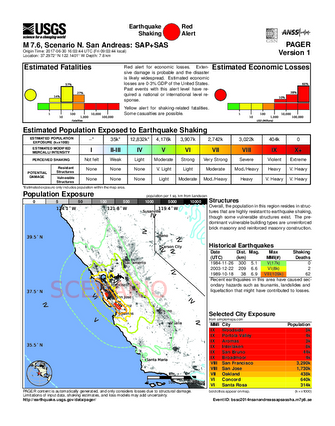

In [26]:
img = mpimg.imread(str(PAGER_PNG))
h, w = img.shape[:2]
fig, ax = plt.subplots(figsize=(w/300, h/300), dpi=150)
ax.imshow(img, interpolation='lanczos')
ax.axis('off')
plt.tight_layout(pad=0)
plt.show()

---

End of Scenario Notebook